<a href="https://colab.research.google.com/github/pattmikyu/PosFIAP/blob/main/performancedospedidos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Performance dos Pedidos**


### INTRODUÇÃO - CONTEXTO
O dataset público da Olist, com registros de 2016 a 2018, permitiu analisar vendas, pagamentos, frete e produtos a partir de tabelas através dos pedidos, itens e pagamentos.
A proposta analítica consistiu em transformar dados transacionais em evidências para decisões de negócio, focando em crescimento de receita, comportamento do volume de pedidos e identificação de gargalos operacionais ligados à logística.

Documentação: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce


In [ ]:
import csv
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

##Importando 5 datasets

In [ ]:
# Lê o arquivo orders
df_orders = pd.read_csv('/content/sample_data/olist_orders_dataset.csv')
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
# Lê o arquivo CSV
df_order_items = pd.read_csv('/content/sample_data/olist_order_items_dataset.csv')
df_order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
# Categorias
df_category = pd.read_csv('/content/sample_data/olist_products_dataset.csv')
df_category.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [ ]:
df_order_payments = pd.read_csv('/content/sample_data/olist_order_payments_dataset.csv')
df_order_payments.head()


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


# **Tabela de Performance dos Pedidos**

In [ ]:
# Relacionar tabela de pedidos e de itens
df_relacao_pedidos = pd.merge(df_orders, df_order_items, on='order_id', how = 'inner')
df_relacao_pedidos.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [ ]:
#Relacionar tabela acima com pagamentos
df_relacao_final = pd.merge(df_relacao_pedidos, df_order_payments, on='order_id', how = 'inner')
df_relacao_final.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,1,credit_card,3,179.12


In [ ]:
# Receita por pedido
df_relacao_final["receita_item"] = df_relacao_final["price"] + df_relacao_final["freight_value"]

# Converter a coluna 'order_purchase_timestamp' para datetime

df_relacao_final["order_purchase_timestamp"] = pd.to_datetime(df_relacao_final["order_purchase_timestamp"])
df_relacao_final["mes_ano"] = df_relacao_final["order_purchase_timestamp"].dt.to_period("M").astype(str)


# **Gráfico de Receita e Números de Pedidos Mês/Ano**

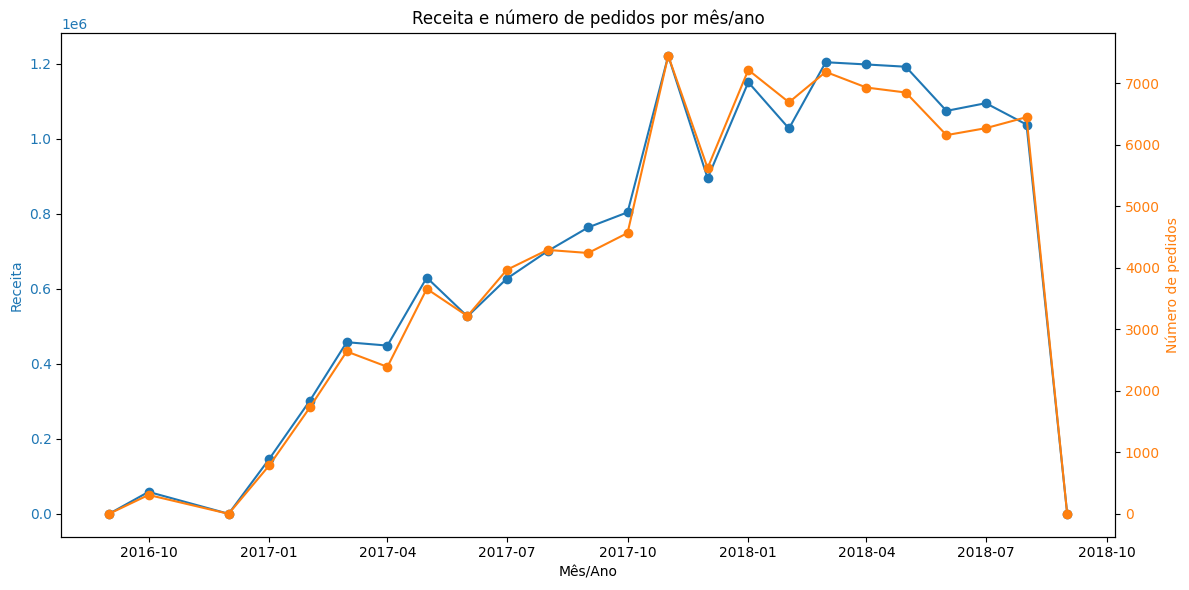

In [ ]:
# Agrupar por mês/ano e agregar somando a receita e contando os pedidos
mensal = (
    df_relacao_final.groupby(df_relacao_final["order_purchase_timestamp"].dt.to_period("M"))
      .agg(
          receita=("receita_item", "sum"),
          pedidos=("order_id", "nunique")
      )
      .reset_index()
)

mensal["order_purchase_timestamp"] = mensal["order_purchase_timestamp"].dt.to_timestamp()

# Plotando o gráfico de linhas
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(mensal["order_purchase_timestamp"], mensal["receita"], color="tab:blue", marker="o", label="Receita")
ax1.set_xlabel("Mês/Ano")
ax1.set_ylabel("Receita", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(mensal["order_purchase_timestamp"], mensal["pedidos"], color="tab:orange", marker="o", label="Pedidos")
ax2.set_ylabel("Número de pedidos", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title("Receita e número de pedidos por mês/ano")
plt.tight_layout()
plt.show()

# O gráfico mostra que receita e número de pedidos caminham muito próximos na maior parte do período, o que sugere que o crescimento consistente. Entretanto, há divergências significantes em alguns meses, p.ex., abril/18 a julho/18

#Analisando métodos de pagamento

/tmp/ipykernel_25407/2339403587.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  mensal_pag["mes_ano_dt"] = pd.to_datetime(mensal_pag["mes_ano"])


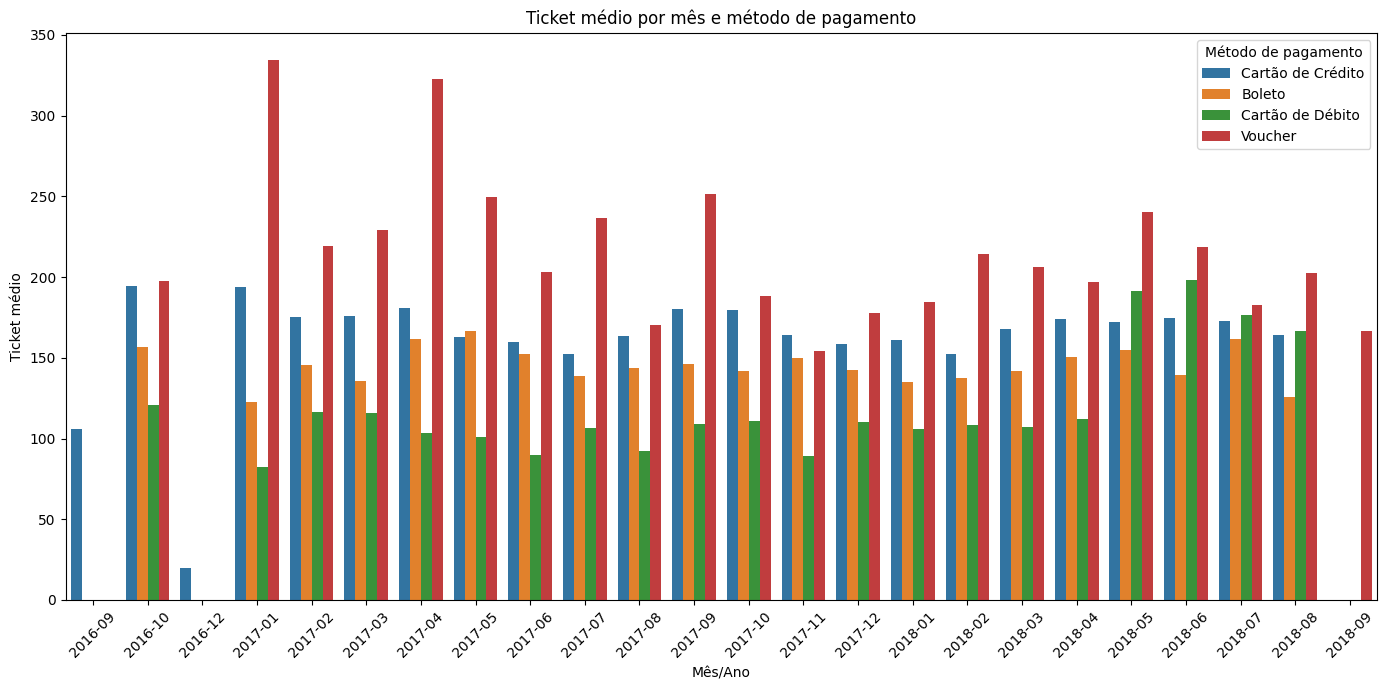

In [ ]:


#Normalizando dados
df_relacao_final['payment_type'] = df_relacao_final['payment_type'].replace({
    'credit_card': 'Cartão de Crédito',
    'boleto': 'Boleto',
    'voucher': 'Voucher',
    'debit_card': 'Cartão de Débito'
})

df = df_relacao_final.copy()

df["mes_ano"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str)

# agrega por mês e método de pagamento
mensal_pag = (
    df.groupby(["mes_ano", "payment_type"], as_index=False)
      .agg(
          receita=("receita_item", "sum"),
          pedidos=("order_id", "nunique")
      )
)

# ticket médio
mensal_pag["ticket_medio"] = mensal_pag["receita"] / mensal_pag["pedidos"]

# ordenar mês corretamente
mensal_pag["mes_ano_dt"] = pd.to_datetime(mensal_pag["mes_ano"])
mensal_pag = mensal_pag.sort_values("mes_ano_dt")

# gráfico
plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=mensal_pag,
    x="mes_ano",
    y="ticket_medio",
    hue="payment_type"
)

plt.title("Ticket médio por mês e método de pagamento")
plt.xlabel("Mês/Ano")
plt.ylabel("Ticket médio")
plt.xticks(rotation=45)
plt.legend(title="Método de pagamento")

plt.tight_layout()
plt.show()


# O gráfico aindica que o método de pagamento mais utilizado é o voucher, mas sozinho não explica os outliers


/tmp/ipykernel_25407/2910135159.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


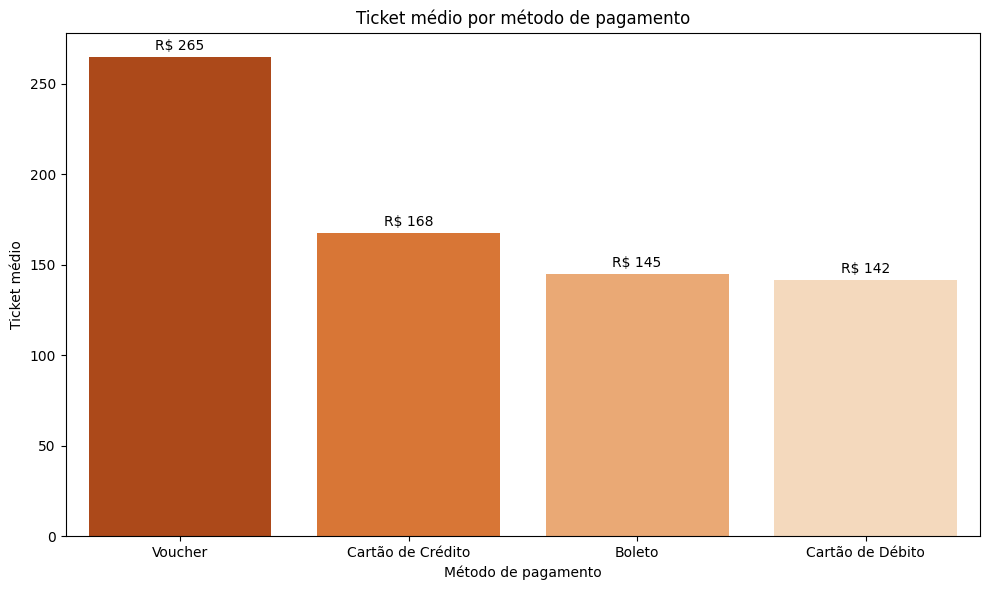

In [ ]:
df1 = df_relacao_final.copy()

# valor total por pedido e método de pagamento
pedido_pag = (
    df1.groupby(["order_id", "payment_type"], as_index=False)
      .agg(receita_pedido=("receita_item", "sum"))
)

# remover duplicidades caso existam múltiplas linhas de pagamento por pedido
pedido_pag = pedido_pag.sort_values(["order_id", "receita_pedido"], ascending=[True, False])
pedido_pag = pedido_pag.drop_duplicates("order_id")

# resumo por método de pagamento
resumo = (
    pedido_pag.groupby("payment_type")
    .agg(
        pedidos=("order_id", "nunique"),
        ticket_medio=("receita_pedido", "mean"),
        mediana_ticket=("receita_pedido", "median")
    )
    .reset_index()


.sort_values("ticket_medio", ascending=False)
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=resumo,
    x="payment_type",
    y="ticket_medio",
    palette="Oranges_r"
)

plt.title("Ticket médio por método de pagamento")
plt.xlabel("Método de pagamento")
plt.ylabel("Ticket médio")

# rótulos nas barras
for container in ax.containers:
    ax.bar_label(container, fmt="R$ %.0f", padding=3)

plt.tight_layout()
plt.show()

### O gráfico reforça a premissa indicada acima

# **Relação de Receita por Categoria**

In [ ]:
#Relacionar tabela relação final com categorias de produtos
df_relacao_categorias = pd.merge(df_relacao_final, df_category, on='product_id', how = 'inner')
df_relacao_categorias.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,receita_item,mes_ano,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,38.71,2017-10,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,38.71,2017-10,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,38.71,2017-10,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,141.46,2018-07,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,179.12,2018-08,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0


/tmp/ipykernel_25407/612142620.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


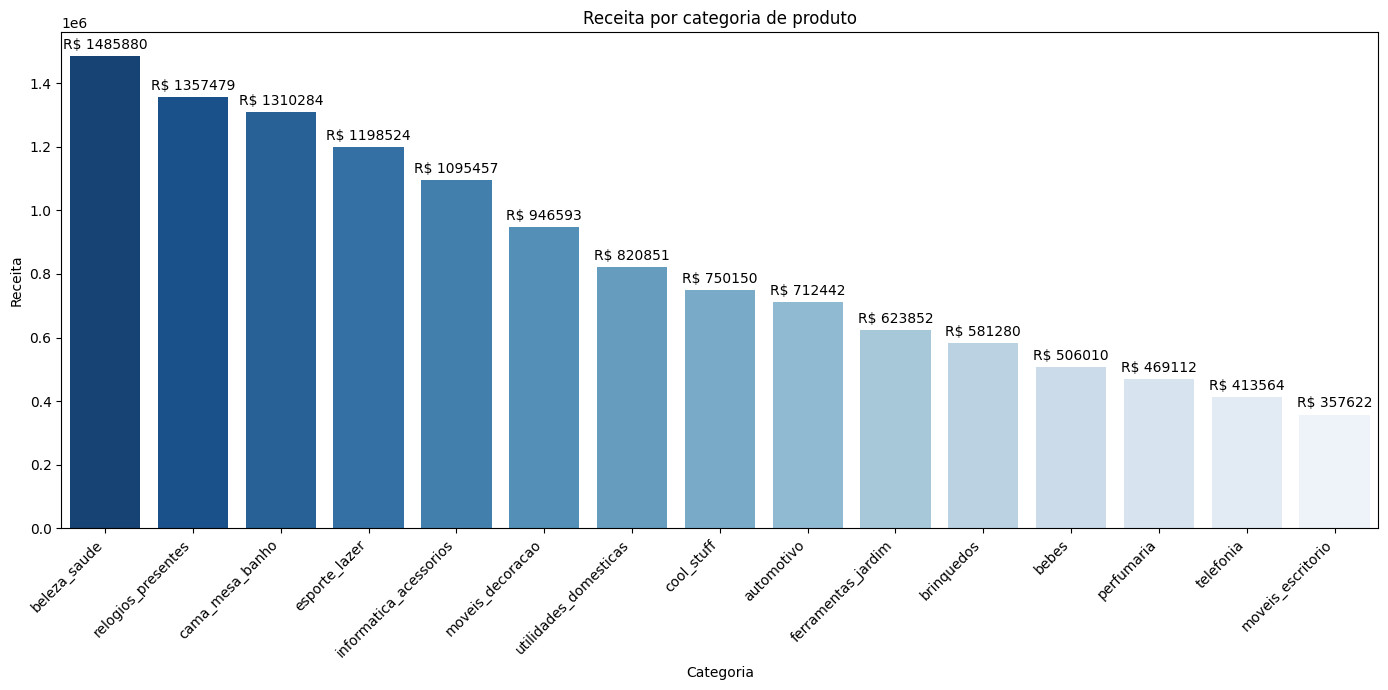

In [ ]:
df2 = df_relacao_categorias.copy()

# receita por item
df2["receita_item"] = df2["price"] + df2["freight_value"]

# agregação por categoria
cat = (
    df2.groupby("product_category_name", as_index=False)
      .agg(
          receita=("receita_item", "sum"),
          pedidos=("order_id", "nunique"),
          ticket_medio=("receita_item", "mean")
      )
)

# ordenar pelas maiores receitas
cat = cat.sort_values("receita", ascending=False).head(15)

plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=cat,
    x="product_category_name",
    y="receita",
    palette="Blues_r"
)

plt.title("Receita por categoria de produto")
plt.xlabel("Categoria")
plt.ylabel("Receita")
plt.xticks(rotation=45, ha="right")

# rótulos nas barras
for container in ax.containers:
    ax.bar_label(container, fmt="R$ %.0f", padding=3)

plt.tight_layout()
plt.show()

O gráfico demonstra quais as categorias mais rentáveis, que nos indica a refletir sobre o frete

/tmp/ipykernel_25407/2941009484.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  top_cat_mes["mes_ano_dt"] = pd.to_datetime(top_cat_mes["mes_ano"])


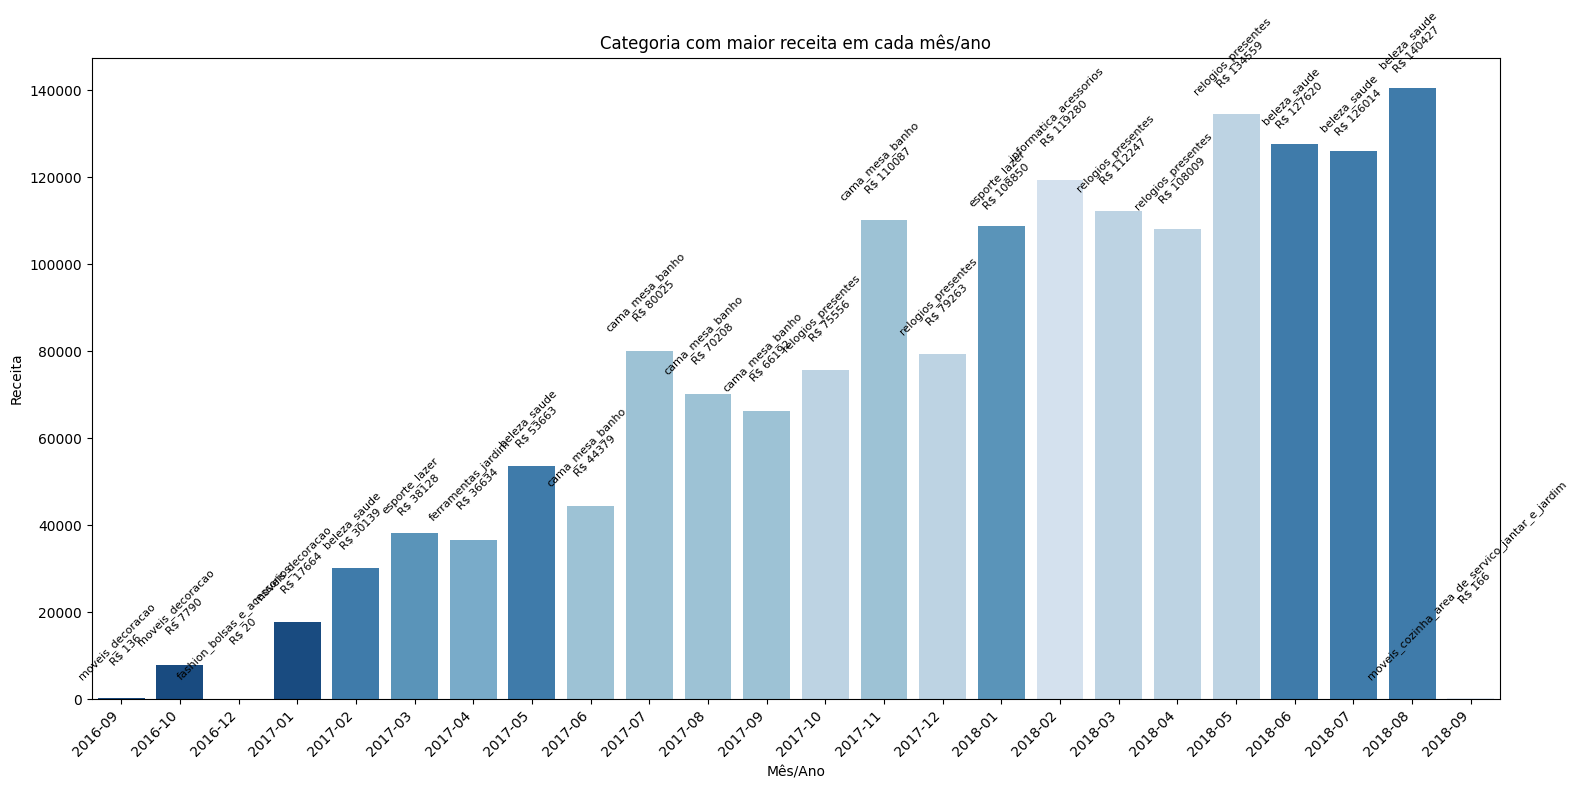

In [ ]:
df3 = df_relacao_categorias.copy()

# mês/ano
df3["mes_ano"] = df3["order_purchase_timestamp"].dt.to_period("M").astype(str)

# receita por mês e categoria
mensal_cat = (
    df3.groupby(["mes_ano", "product_category_name"], as_index=False)
      .agg(receita=("receita_item", "sum"))
)

# pegar a categoria mais vendida de cada mês
top_cat_mes = (
    mensal_cat.sort_values(["mes_ano", "receita"], ascending=[True, False])
              .groupby("mes_ano")
              .head(1)
              .reset_index(drop=True)
)

# ordenar mês corretamente
top_cat_mes["mes_ano_dt"] = pd.to_datetime(top_cat_mes["mes_ano"])
top_cat_mes = top_cat_mes.sort_values("mes_ano_dt")


plt.figure(figsize=(16, 8))
ax = sns.barplot(
    data=top_cat_mes,
    x="mes_ano",
    y="receita",
    hue="product_category_name",
    dodge=False,
    palette="Blues_r"
)

plt.title("Categoria com maior receita em cada mês/ano")
plt.xlabel("Mês/Ano")
plt.ylabel("Receita")
plt.xticks(rotation=45, ha="right")

# remover legenda
ax.legend_.remove()

# adicionar rótulo de valor e categoria em cada barra
for i, row in top_cat_mes.reset_index(drop=True).iterrows():
    ax.text(
        i,
        row["receita"] + 2000,
        f'{row["product_category_name"]}\nR$ {row["receita"]:.0f}',
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=45
    )

plt.tight_layout()
plt.show()

O gráfico acima indica quais as categorias que mais trouxeram receita por mês/ano para sustentar a análise dos outliers

# Comportamento do Frete

In [ ]:

df4 = df_relacao_categorias.copy()

# datas e limpeza
df4["order_purchase_timestamp"] = pd.to_datetime(df4["order_purchase_timestamp"])
df4["mes_ano"] = df4["order_purchase_timestamp"].dt.to_period("M").astype(str)
df4["product_weight_g"] = pd.to_numeric(df4["product_weight_g"], errors="coerce")

# frete médio por mês/categoria
base = (
    df4.groupby(["mes_ano", "product_category_name"], as_index=False)
      .agg(
          frete_medio=("freight_value", "mean"),
          peso_moda=("product_weight_g", lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA),
          pedidos=("order_id", "nunique")
      )
)

# escolher a categoria mais frequente em cada mês
# critério: maior número de pedidos; em empate, maior frete médio
linha_mes = (
    base.sort_values(["mes_ano", "pedidos", "frete_medio"], ascending=[True, False, False])
        .groupby("mes_ano", as_index=False)
        .head(1)
        .reset_index(drop=True)
)

linha_mes

,mes_ano,product_category_name,frete_medio,peso_moda,pedidos
0,2016-09,moveis_decoracao,31.670000,1400.0,1
1,2016-10,moveis_decoracao,18.603200,900.0,51
2,2016-12,fashion_bolsas_e_acessorios,8.720000,200.0,1
3,2017-01,moveis_decoracao,16.176970,700.0,137
4,2017-02,moveis_decoracao,19.774377,700.0,221
5,2017-03,moveis_decoracao,18.301924,400.0,265
6,2017-04,cama_mesa_banho,17.372378,1383.0,234
7,2017-05,cama_mesa_banho,16.985298,1383.0,329
8,2017-06,cama_mesa_banho,16.899190,1383.0,335
9,2017-07,cama_mesa_banho,18.494984,9750.0,513


### Tabela que indica o valor do frete e nos auxilia a comparar o peso e o valor do frete de cada categoria de produto

In [ ]:
df4 = df_relacao_categorias.copy()

# limpeza
df4["product_weight_g"] = pd.to_numeric(
    df4["product_weight_g"],
    errors="coerce"
)

resultado = (
    df4.groupby("product_category_name", as_index=False)
       .agg(
           frete_medio=("freight_value", "mean"),
           peso_moda=("product_weight_g",
                      lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA),
           receita_item=("receita_item", "sum")
       )
       .sort_values("receita_item", ascending=False)
       .reset_index(drop=True)
)

resultado

,product_category_name,frete_medio,peso_moda,receita_item
0,beleza_saude,18.905384,200.0,1485880.29
1,relogios_presentes,16.825596,250.0,1357478.82
2,cama_mesa_banho,18.416063,1383.0,1310284.13
3,esporte_lazer,19.511236,150.0,1198524.35
4,informatica_acessorios,18.953156,200.0,1095456.98
...,...,...,...,...
68,flores,14.814242,850.0,1598.91
69,casa_conforto_2,13.589355,700.0,1194.44
70,cds_dvds_musicais,16.070714,550.0,954.99
71,fashion_roupa_infanto_juvenil,11.938750,100.0,665.36


In [ ]:
resultado.head(16)

,product_category_name,frete_medio,peso_moda,receita_item
0,beleza_saude,18.905384,200.0,1485880.29
1,relogios_presentes,16.825596,250.0,1357478.82
2,cama_mesa_banho,18.416063,1383.0,1310284.13
3,esporte_lazer,19.511236,150.0,1198524.35
4,informatica_acessorios,18.953156,200.0,1095456.98
5,moveis_decoracao,20.757003,2600.0,946593.12
6,utilidades_domesticas,20.974064,200.0,820851.24
7,cool_stuff,22.031736,1200.0,750150.02
8,automotivo,21.851923,100.0,712442.08
9,ferramentas_jardim,23.094543,1550.0,623851.98


# Houve um aumento significativo no frete a partir de março de 2018, o que ocasiona o outlier de aumento de receita X número de pedidos.